# Breast Cancer Wisconsin Diagnostic — ML Classifier

## Business Question
> **Can we develop a machine learning model to assist radiologists in distinguishing malignant from benign breast masses using cell morphology features, in order to reduce unnecessary biopsies while maintaining high cancer detection rates?**

## Dataset
The [Wisconsin Breast Cancer Diagnostic dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) contains 569 samples with 30 real-valued features derived from digitized images of fine needle aspirates (FNAs) of breast masses. Features describe characteristics of cell nuclei such as radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry — each measured as mean, standard error, and worst (largest) value.

## Notebook Structure
1. Exploratory Data Analysis (EDA)
2. Preprocessing
3. Baseline Model — Logistic Regression
4. Advanced Models — Random Forest & SVM
5. Evaluation — AUC-ROC, Confusion Matrix, Threshold Tuning

---
## 1. Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, roc_curve, confusion_matrix
)

import warnings
warnings.filterwarnings('ignore')

# Color palette for consistent visuals
MALIGNANT_COLOR = '#e74c3c'
BENIGN_COLOR    = '#2ecc71'

print('Libraries loaded successfully.')

Libraries loaded successfully.


### 1.1 Load and Inspect the Data

We use `sklearn`'s built-in loader, which is identical to the UCI WDBC dataset.
The `.info()` method gives us a concise summary of column types and non-null counts.

In [2]:
# Load dataset
data = load_breast_cancer()
cancer = pd.DataFrame(data.data, columns=data.feature_names)

# Map target: sklearn uses 0=Malignant, 1=Benign — re-label for clarity
cancer['diagnosis'] = pd.Categorical(
    np.where(data.target == 0, 'Malignant', 'Benign'),
    categories=['Malignant', 'Benign']
)

print(f'Dataset shape: {cancer.shape}')
print(f'Features: {data.feature_names.tolist()}\n')
cancer.info()

Dataset shape: (569, 31)
Features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   mean radius              569 non-null    float64 
 1   mean texture             569 non-null    float64 
 2   mean perimeter           569 non-null    float64 
 3   mean area     

In [3]:
# Summary statistics
cancer.describe().round(2)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


### 1.2 Data Cleaning

Before analysis, we check for issues that would affect model quality: missing values, duplicate rows, and constant/zero-variance features.

In [4]:
# --- Missing values ---
missing = cancer.isnull().sum()
print('=== Missing Values ===')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

# --- Duplicate rows ---
dupes = cancer.duplicated().sum()
print(f'\n=== Duplicate Rows ===')
print(f'{dupes} duplicate row(s) found.')
if dupes > 0:
    cancer = cancer.drop_duplicates()
    print(f'Duplicates removed. New shape: {cancer.shape}')

# --- Constant / zero-variance features ---
feature_cols = cancer.select_dtypes(include='number').columns
zero_var = [col for col in feature_cols if cancer[col].nunique() == 1]
print(f'\n=== Constant Features (zero variance) ===')
print(zero_var if zero_var else 'None found.')

# --- Outlier summary (IQR method, informational only) ---
print('\n=== Outlier Count per Feature (IQR method) ===')
outlier_counts = {}
for col in feature_cols:
    Q1, Q3 = cancer[col].quantile(0.25), cancer[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((cancer[col] < Q1 - 1.5 * IQR) | (cancer[col] > Q3 + 1.5 * IQR)).sum()
    if outliers > 0:
        outlier_counts[col] = outliers

outlier_df = pd.Series(outlier_counts).sort_values(ascending=False)
print(outlier_df.to_string() if not outlier_df.empty else 'No outliers detected.')
print(f'\nNote: Outliers are retained — they may represent clinically significant extreme cases.')

=== Missing Values ===
No missing values found.

=== Duplicate Rows ===
0 duplicate row(s) found.

=== Constant Features (zero variance) ===
None found.

=== Outlier Count per Feature (IQR method) ===
area error                 65
radius error               38
perimeter error            38
worst area                 35
smoothness error           30
fractal dimension error    28
compactness error          28
symmetry error             27
mean area                  25
worst fractal dimension    24
worst symmetry             23
concavity error            22
texture error              20
concave points error       19
mean concavity             18
worst radius               17
worst compactness          16
mean compactness           16
mean fractal dimension     15
worst perimeter            15
mean symmetry              15
mean radius                14
mean perimeter             13
worst concavity            12
mean concave points        10
worst smoothness            7
mean texture       

### 1.3 Class Distribution

Understanding class balance is critical. If one class dominates, accuracy becomes a misleading metric.

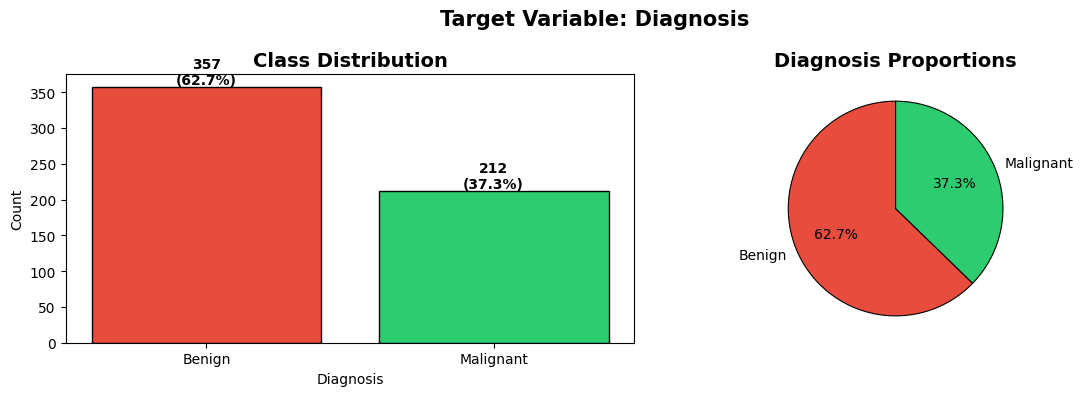

           Count  Percentage (%)
diagnosis                       
Benign       357            62.7
Malignant    212            37.3


In [5]:
class_counts = cancer['diagnosis'].value_counts()
class_pcts   = cancer['diagnosis'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = [MALIGNANT_COLOR, BENIGN_COLOR]
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis')
axes[0].set_ylabel('Count')
for i, (val, pct) in enumerate(zip(class_counts.values, class_pcts.values)):
    axes[0].text(i, val + 4, f'{val}\n({pct:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values, labels=class_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[1].set_title('Diagnosis Proportions', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Diagnosis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(pd.DataFrame({'Count': class_counts, 'Percentage (%)': class_pcts.round(1)}))

**Observation:** The dataset is moderately imbalanced (~37% Malignant, ~63% Benign). We will use stratified splitting and evaluate with sensitivity/specificity rather than accuracy alone.

### 1.4 Feature Distributions by Diagnosis

Overlapping histograms reveal which features best separate the two classes.

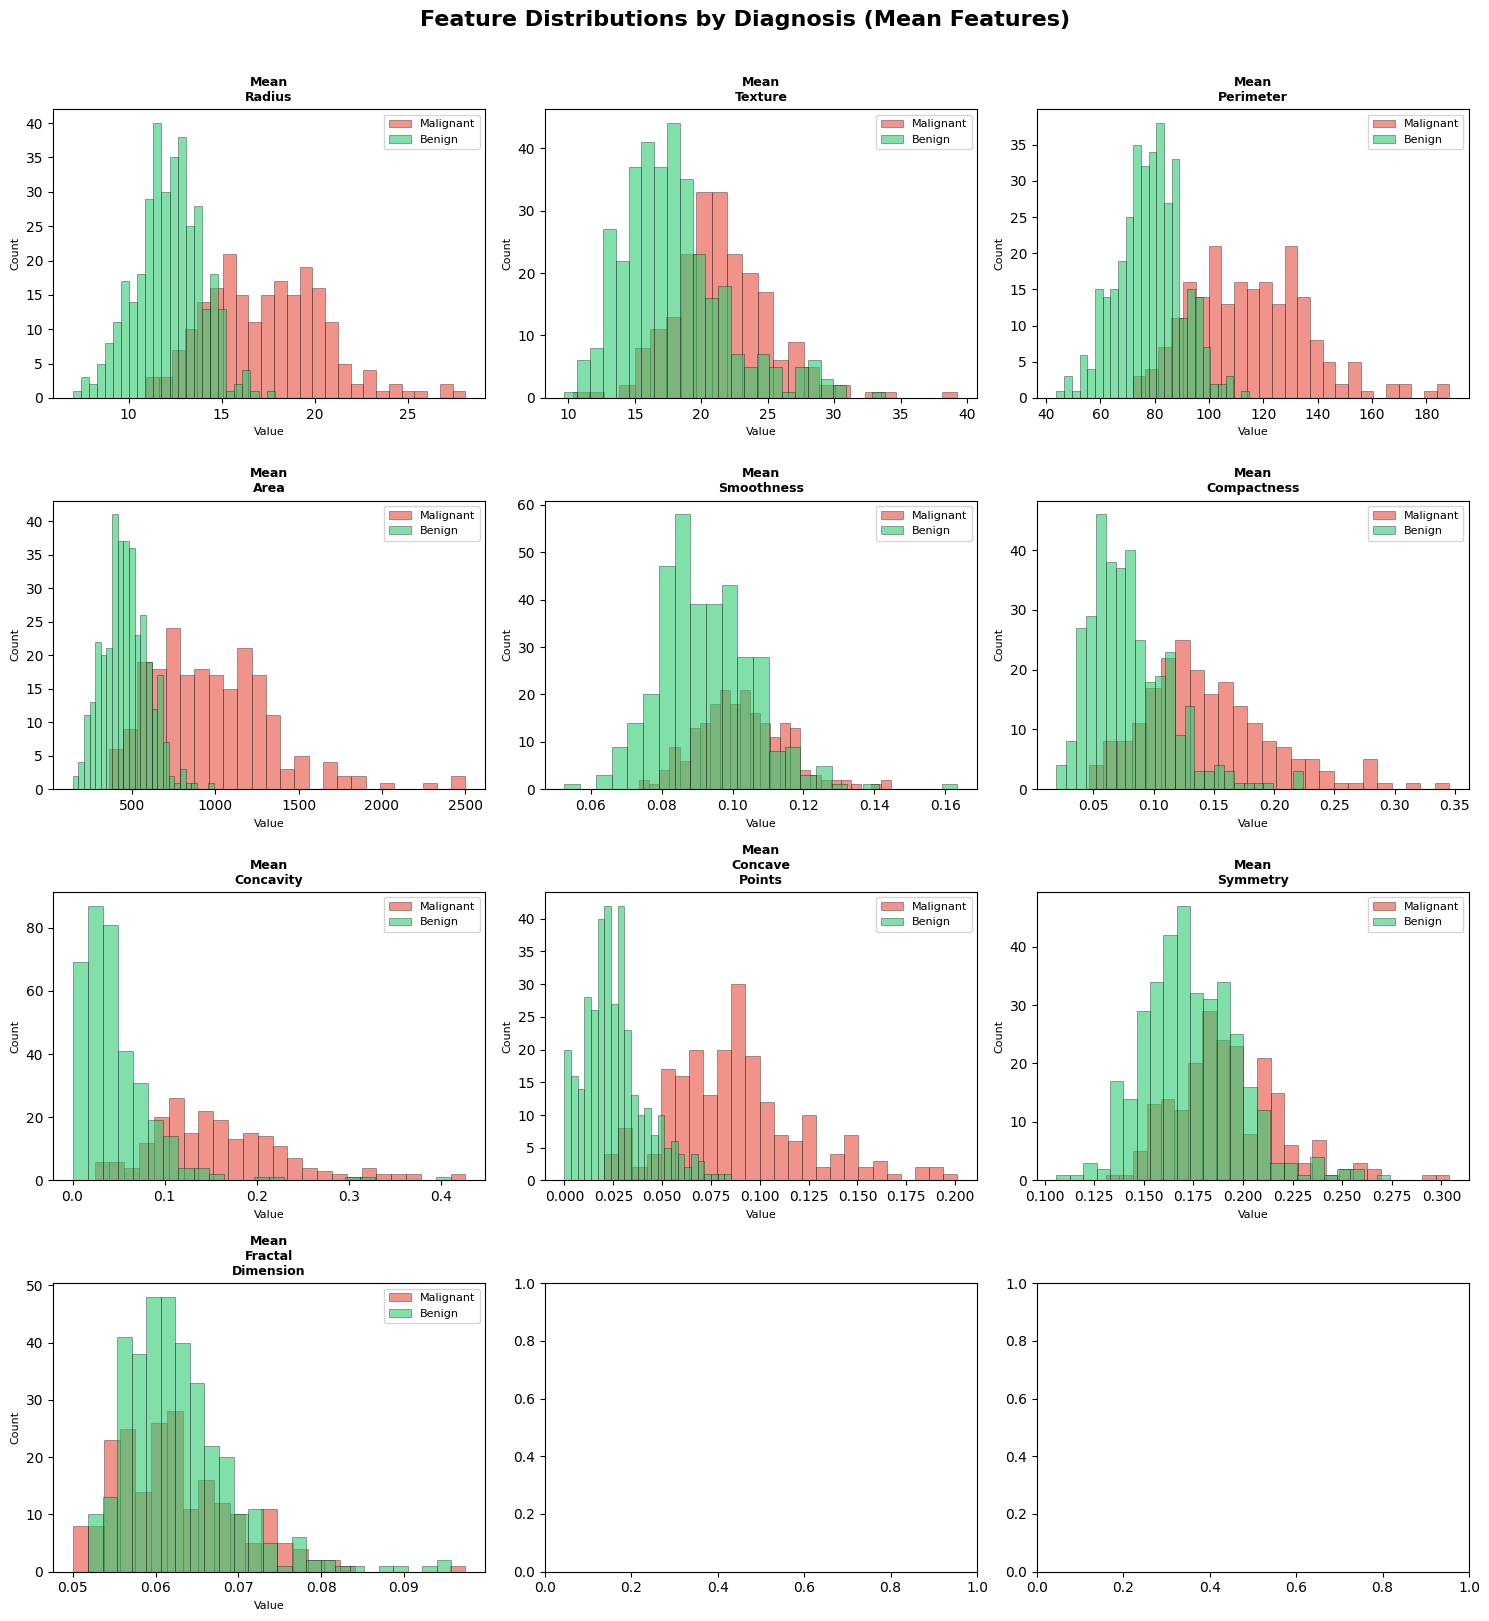

In [6]:
mean_features = [col for col in cancer.columns if col.startswith('mean')]

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    for diagnosis, color in [('Malignant', MALIGNANT_COLOR), ('Benign', BENIGN_COLOR)]:
        subset = cancer[cancer['diagnosis'] == diagnosis][feature]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color,
                     label=diagnosis, edgecolor='black', linewidth=0.4)
    axes[i].set_title(feature.replace(' ', '\n').title(), fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Diagnosis (Mean Features)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.5 Box Plots by Diagnosis

Box plots highlight the median, spread, and outliers for each feature across classes.

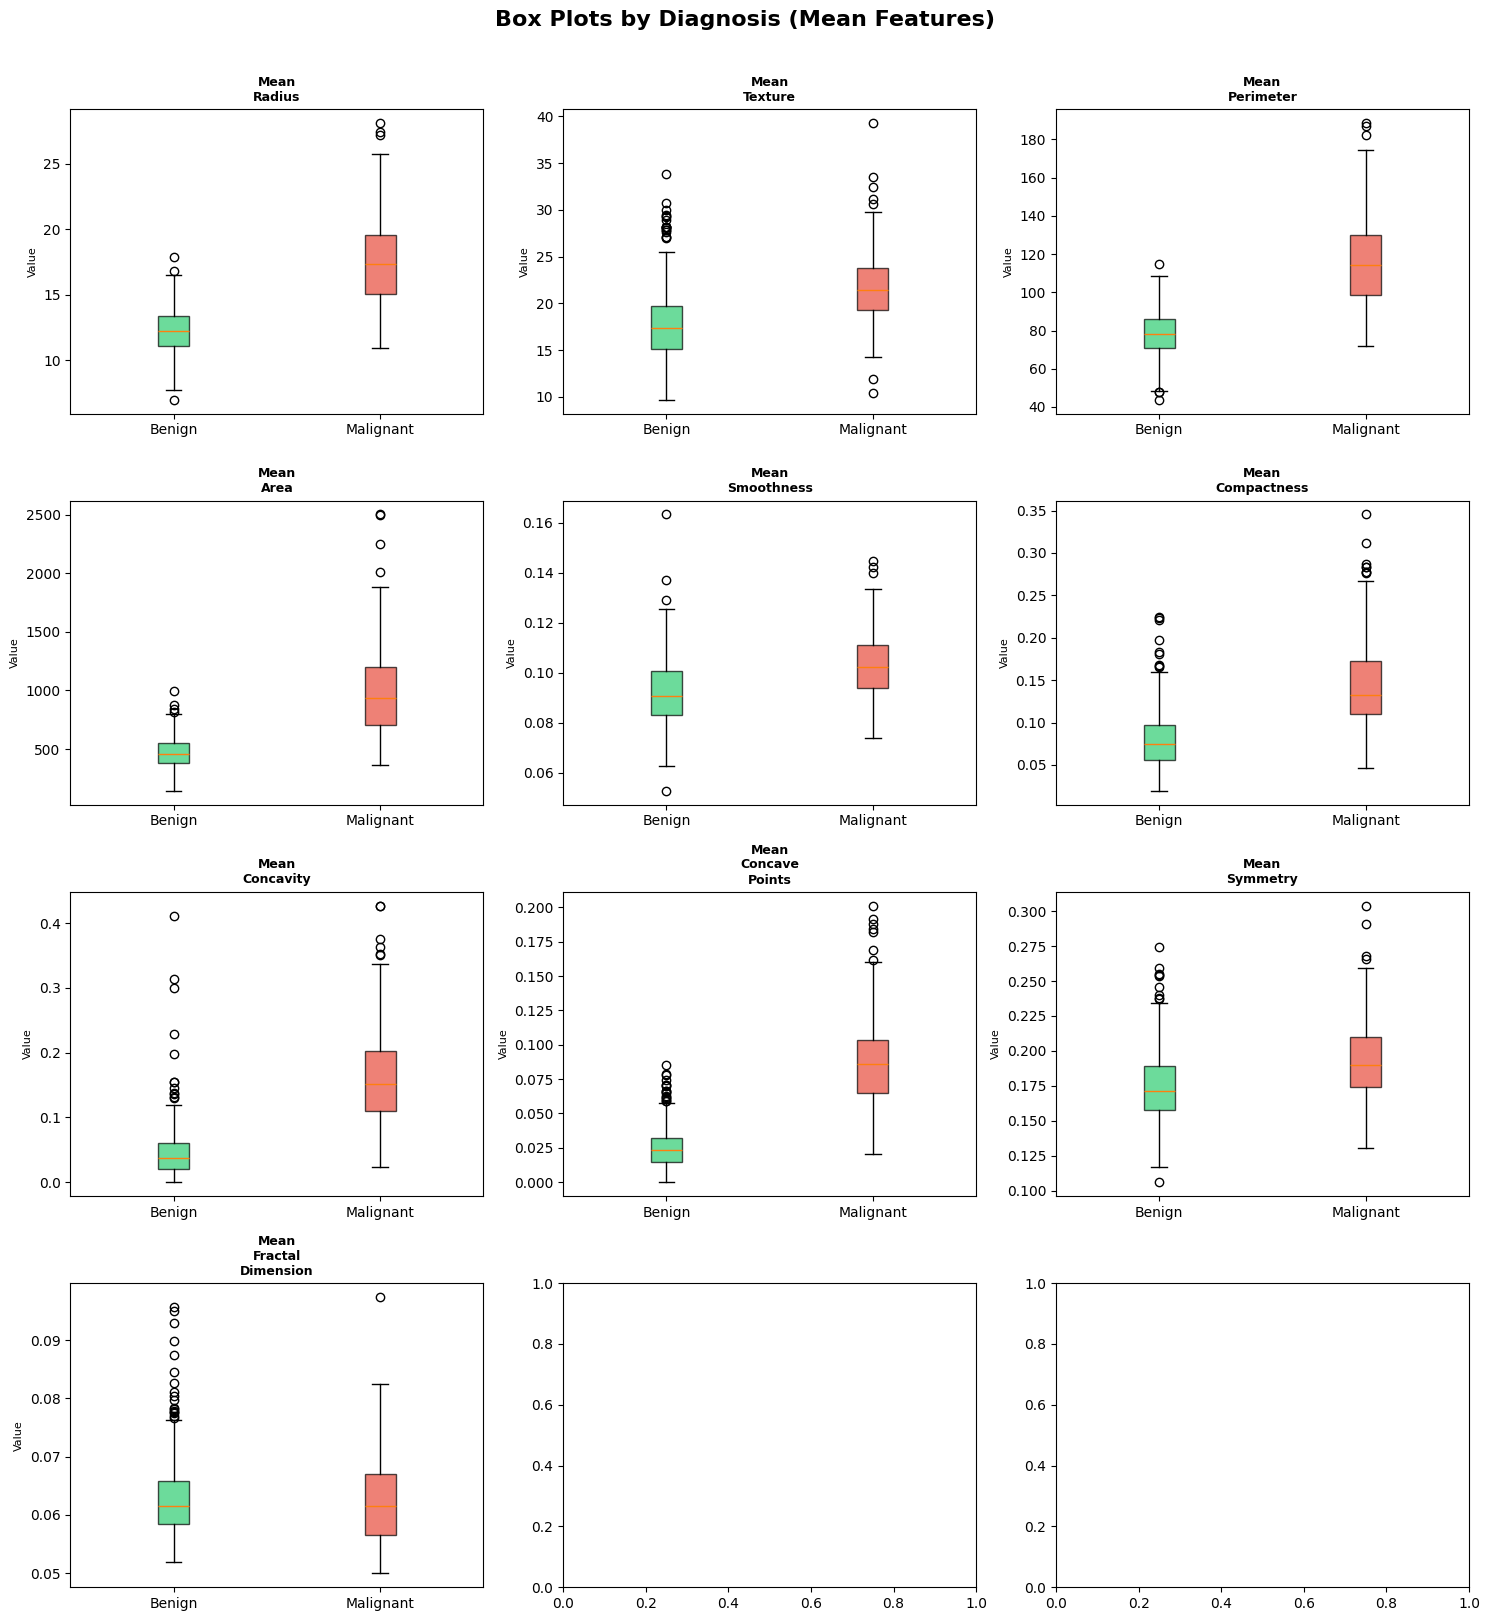

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()

for i, feature in enumerate(mean_features):
    benign    = cancer[cancer['diagnosis'] == 'Benign'][feature]
    malignant = cancer[cancer['diagnosis'] == 'Malignant'][feature]

    bp = axes[i].boxplot(
        [benign, malignant], labels=['Benign', 'Malignant'],
        patch_artist=True, notch=False
    )
    bp['boxes'][0].set_facecolor(BENIGN_COLOR)
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(MALIGNANT_COLOR)
    bp['boxes'][1].set_alpha(0.7)

    axes[i].set_title(feature.replace(' ', '\n').title(), fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value', fontsize=8)

plt.suptitle('Box Plots by Diagnosis (Mean Features)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.6 Scatter Plots — Key Feature Relationships

Following the course notebook pattern, we visualize how pairs of features separate the classes.

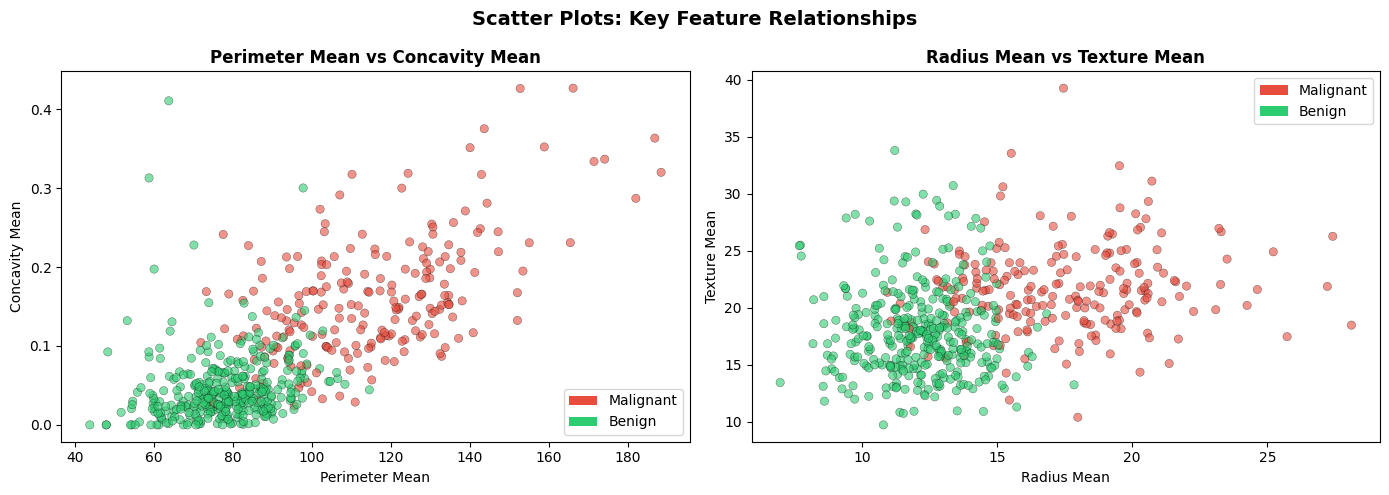

In [8]:
colors_map = cancer['diagnosis'].map({'Malignant': MALIGNANT_COLOR, 'Benign': BENIGN_COLOR})
legend_handles = [
    mpatches.Patch(facecolor=MALIGNANT_COLOR, label='Malignant'),
    mpatches.Patch(facecolor=BENIGN_COLOR,    label='Benign')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Perimeter mean vs Concavity mean (from course notebook)
axes[0].scatter(cancer['mean perimeter'], cancer['mean concavity'],
                c=colors_map, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel('Perimeter Mean')
axes[0].set_ylabel('Concavity Mean')
axes[0].set_title('Perimeter Mean vs Concavity Mean', fontweight='bold')
axes[0].legend(handles=legend_handles)

# Radius mean vs Texture mean
axes[1].scatter(cancer['mean radius'], cancer['mean texture'],
                c=colors_map, alpha=0.6, edgecolors='k', linewidths=0.3)
axes[1].set_xlabel('Radius Mean')
axes[1].set_ylabel('Texture Mean')
axes[1].set_title('Radius Mean vs Texture Mean', fontweight='bold')
axes[1].legend(handles=legend_handles)

plt.suptitle('Scatter Plots: Key Feature Relationships', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.7 Correlation Heatmap

High correlation between features can lead to multicollinearity. We examine the mean features.

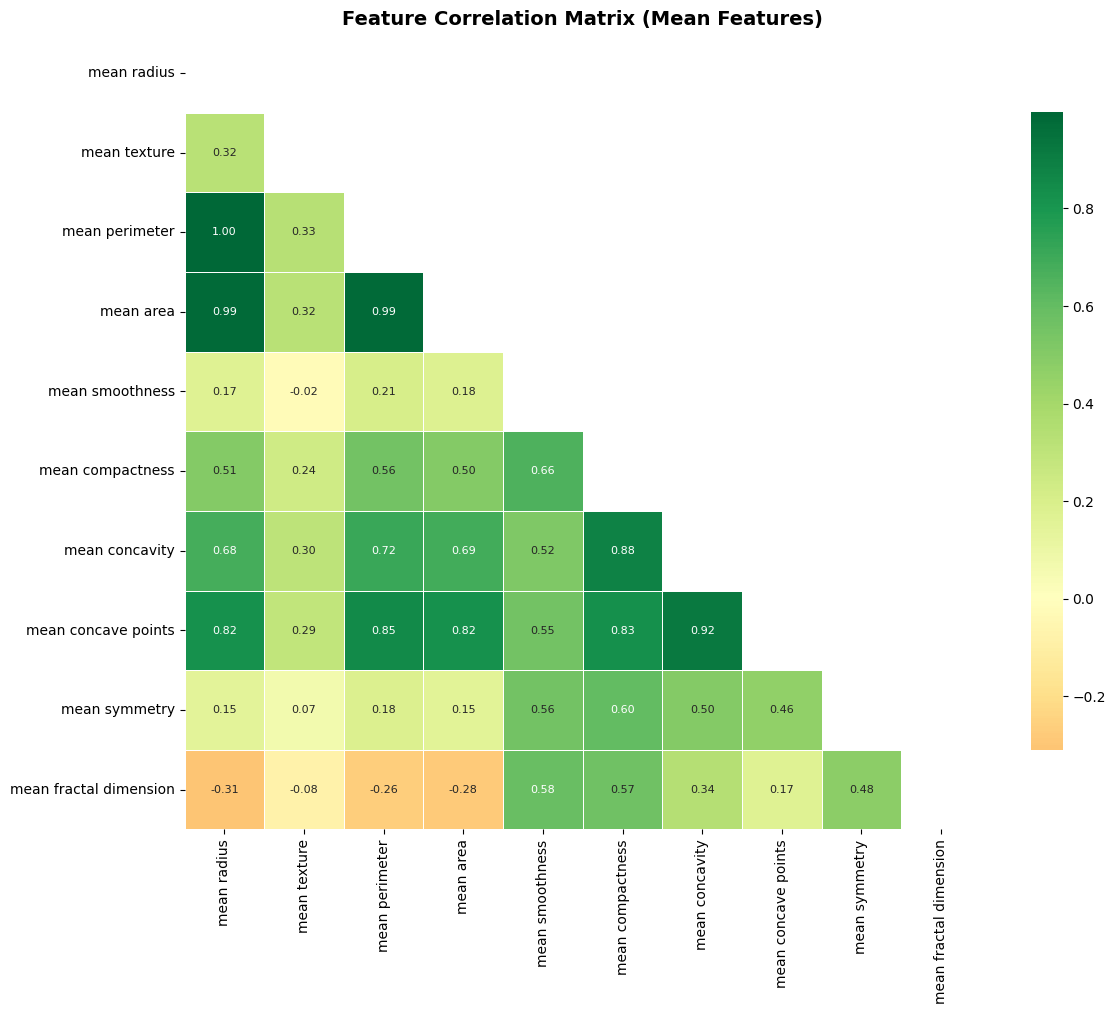

In [9]:
corr_matrix = cancer[mean_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # upper triangle mask

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 8}
)
plt.title('Feature Correlation Matrix (Mean Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Radius, perimeter, and area are highly correlated (expected — they measure the same physical property). This is fine for tree-based models, but worth noting for logistic regression. StandardScaler handles scale differences.

---
## 2. Preprocessing

Steps:
1. Encode the target (`Malignant = 1`, `Benign = 0`)
2. Standardize all features using `StandardScaler` (required for KNN, LR, SVM)
3. Stratified 80/20 train-test split to preserve class proportions

In [10]:
# Encode target
cancer['diagnosis_code'] = cancer['diagnosis'].map({'Malignant': 1, 'Benign': 0})

# Features and target
X       = cancer.drop(columns=['diagnosis', 'diagnosis_code'])
y       = cancer['diagnosis_code']
y_label = cancer['diagnosis']

# Standardize features (following course notebook pattern)
scaler  = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Stratified train-test split
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)
_, _, y_train_label, y_test_label = train_test_split(
    X_scaled, y_label, test_size=0.2, stratify=y_label, random_state=42
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining class distribution:')
print(pd.Series(y_train).value_counts().rename({1: 'Malignant', 0: 'Benign'}))
print(f'\nTest class distribution:')
print(pd.Series(y_test).value_counts().rename({1: 'Malignant', 0: 'Benign'}))

Training set: 455 samples
Test set:     114 samples

Training class distribution:
diagnosis_code
Benign       285
Malignant    170
Name: count, dtype: int64

Test class distribution:
diagnosis_code
Benign       72
Malignant    42
Name: count, dtype: int64


---
## 3. Baseline Model — Logistic Regression

Logistic Regression is our baseline because:
- It is interpretable (clinicians can see which features drive predictions)
- It outputs calibrated probabilities, enabling threshold tuning
- It is a standard starting point in clinical ML literature

In [11]:
lr = LogisticRegression(max_iter=5000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lr).ravel()

print('=== Logistic Regression (Baseline) ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_lr):.4f}  <- cancer detection rate')
print(f'Specificity:            {tn / (tn + fp):.4f}  <- benign correctly identified')
print(f'Precision:              {precision_score(y_test, y_pred_lr):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')
print(f'\nConfusion Matrix:')
print(pd.crosstab(
    y_test_label,
    pd.Categorical(np.where(y_pred_lr == 1, 'Malignant', 'Benign'),
                   categories=['Benign', 'Malignant']),
    rownames=['Actual'], colnames=['Predicted']
))

=== Logistic Regression (Baseline) ===
Accuracy:               0.9649
Sensitivity (Recall):   0.9286  <- cancer detection rate
Specificity:            0.9861  <- benign correctly identified
Precision:              0.9750
AUC-ROC:                0.9960
False Negatives (missed cancers):    3
False Positives (unnecessary biops): 1

Confusion Matrix:
Predicted  Benign  Malignant
Actual                      
Malignant       3         39
Benign         71          1


---
## 4. Advanced Models

### 4.1 Random Forest

Random Forest is an ensemble of decision trees. Advantages for this task:
- Handles correlated features well
- Provides feature importance scores
- Robust to outliers

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_rf).ravel()

print('=== Random Forest (Default) ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_rf):.4f}')
print(f'Specificity:            {tn / (tn + fp):.4f}')
print(f'Precision:              {precision_score(y_test, y_pred_rf):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')
print(f'\nConfusion Matrix:')
print(pd.crosstab(
    y_test_label,
    pd.Categorical(np.where(y_pred_rf == 1, 'Malignant', 'Benign'),
                   categories=['Benign', 'Malignant']),
    rownames=['Actual'], colnames=['Predicted']
))

=== Random Forest (Default) ===
Accuracy:               0.9737
Sensitivity (Recall):   0.9286
Specificity:            1.0000
Precision:              1.0000
AUC-ROC:                0.9929
False Negatives (missed cancers):    3
False Positives (unnecessary biops): 0

Confusion Matrix:
Predicted  Benign  Malignant
Actual                      
Malignant       3         39
Benign         72          0


### 4.2 Support Vector Machine (SVM)

SVM finds the optimal hyperplane separating classes. Works well in high-dimensional spaces and is effective when classes are reasonably separable.

In [13]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_prob_svm = svm.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm).ravel()

print('=== Support Vector Machine ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_svm):.4f}')
print(f'Specificity:            {tn / (tn + fp):.4f}')
print(f'Precision:              {precision_score(y_test, y_pred_svm):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_svm):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')
print(f'\nConfusion Matrix:')
print(pd.crosstab(
    y_test_label,
    pd.Categorical(np.where(y_pred_svm == 1, 'Malignant', 'Benign'),
                   categories=['Benign', 'Malignant']),
    rownames=['Actual'], colnames=['Predicted']
))

=== Support Vector Machine ===
Accuracy:               0.9737
Sensitivity (Recall):   0.9286
Specificity:            1.0000
Precision:              1.0000
AUC-ROC:                0.9954
False Negatives (missed cancers):    3
False Positives (unnecessary biops): 0

Confusion Matrix:
Predicted  Benign  Malignant
Actual                      
Malignant       3         39
Benign         72          0


### 4.3 Hyperparameter Tuning — Random Forest with GridSearchCV

We use `GridSearchCV` with 10-fold cross-validation (following course notebook pattern), optimizing for **recall** — because in a clinical setting, missing a cancer is far more costly than an unnecessary biopsy.

In [14]:
param_grid_rf = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=10,
    scoring='recall',   # prioritize cancer detection
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print(f'Best parameters: {grid_rf.best_params_}')
print(f'Best CV Recall:  {grid_rf.best_score_:.4f}')

best_rf = grid_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_best_rf).ravel()

print(f'\n=== Tuned Random Forest (Test Set) ===')
print(f'Accuracy:               {accuracy_score(y_test, y_pred_best_rf):.4f}')
print(f'Sensitivity (Recall):   {recall_score(y_test, y_pred_best_rf):.4f}')
print(f'Specificity:            {tn / (tn + fp):.4f}')
print(f'Precision:              {precision_score(y_test, y_pred_best_rf):.4f}')
print(f'AUC-ROC:                {roc_auc_score(y_test, y_prob_best_rf):.4f}')
print(f'False Negatives (missed cancers):    {fn}')
print(f'False Positives (unnecessary biops): {fp}')

Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV Recall:  0.9412

=== Tuned Random Forest (Test Set) ===
Accuracy:               0.9649
Sensitivity (Recall):   0.9048
Specificity:            1.0000
Precision:              1.0000
AUC-ROC:                0.9950
False Negatives (missed cancers):    4
False Positives (unnecessary biops): 0


---
## 5. Evaluation

### 5.1 Model Comparison Table

In [15]:
model_results = []
for name, (y_pred, y_prob) in {
    'Logistic Regression (Baseline)': (y_pred_lr,       y_prob_lr),
    'Random Forest (Default)':        (y_pred_rf,       y_prob_rf),
    'Random Forest (Tuned)':          (y_pred_best_rf,  y_prob_best_rf),
    'SVM':                            (y_pred_svm,      y_prob_svm),
}.items():
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    model_results.append({
        'Model':                          name,
        'Accuracy':                       round(accuracy_score(y_test, y_pred),  4),
        'Sensitivity (Recall)':           round(recall_score(y_test, y_pred),    4),
        'Specificity':                    round(tn / (tn + fp),                  4),
        'Precision':                      round(precision_score(y_test, y_pred), 4),
        'AUC-ROC':                        round(roc_auc_score(y_test, y_prob),   4),
        'Missed Cancers (FN)':            fn,
        'Unnecessary Biopsies (FP)':      fp,
    })

results_df = pd.DataFrame(model_results).set_index('Model')
results_df

,Accuracy,Sensitivity (Recall),Specificity,Precision,AUC-ROC,Missed Cancers (FN),Unnecessary Biopsies (FP)
Model,,,,,,,
Logistic Regression (Baseline),0.9649,0.9286,0.9861,0.975,0.9960,3,1
Random Forest (Default),0.9737,0.9286,1.0000,1.000,0.9929,3,0
Random Forest (Tuned),0.9649,0.9048,1.0000,1.000,0.9950,4,0
SVM,0.9737,0.9286,1.0000,1.000,0.9954,3,0


### 5.2 ROC Curves — All Models

The ROC curve shows the trade-off between sensitivity and specificity at every possible threshold. A model closer to the top-left corner is better.

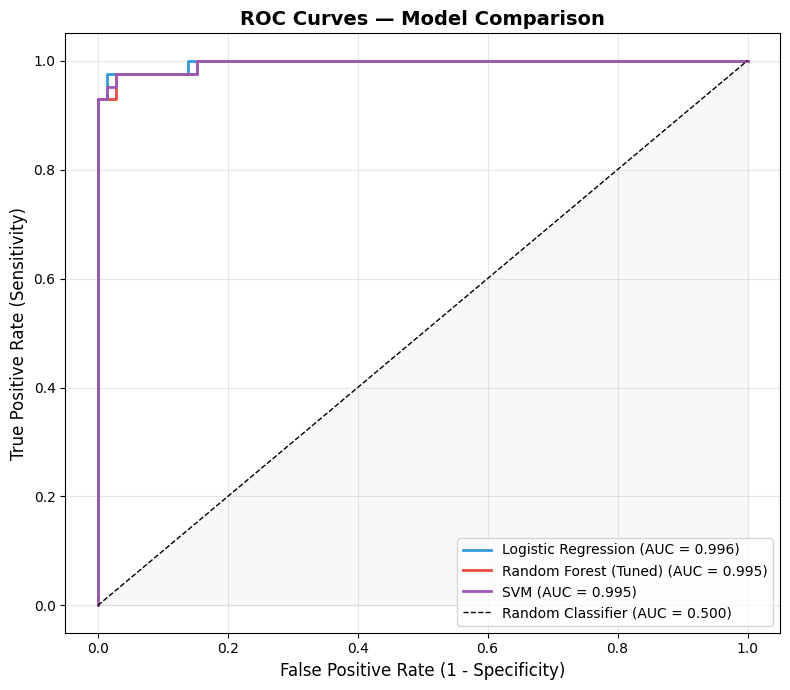

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

roc_models = {
    'Logistic Regression': (y_prob_lr,       '#3498db'),
    'Random Forest (Tuned)': (y_prob_best_rf, '#e74c3c'),
    'SVM':                 (y_prob_svm,       '#9b59b6'),
}

for name, (probs, color) in roc_models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.3 Feature Importance (Random Forest)

Feature importance scores tell us which cell morphology measurements are most predictive. This is valuable for clinical interpretation.

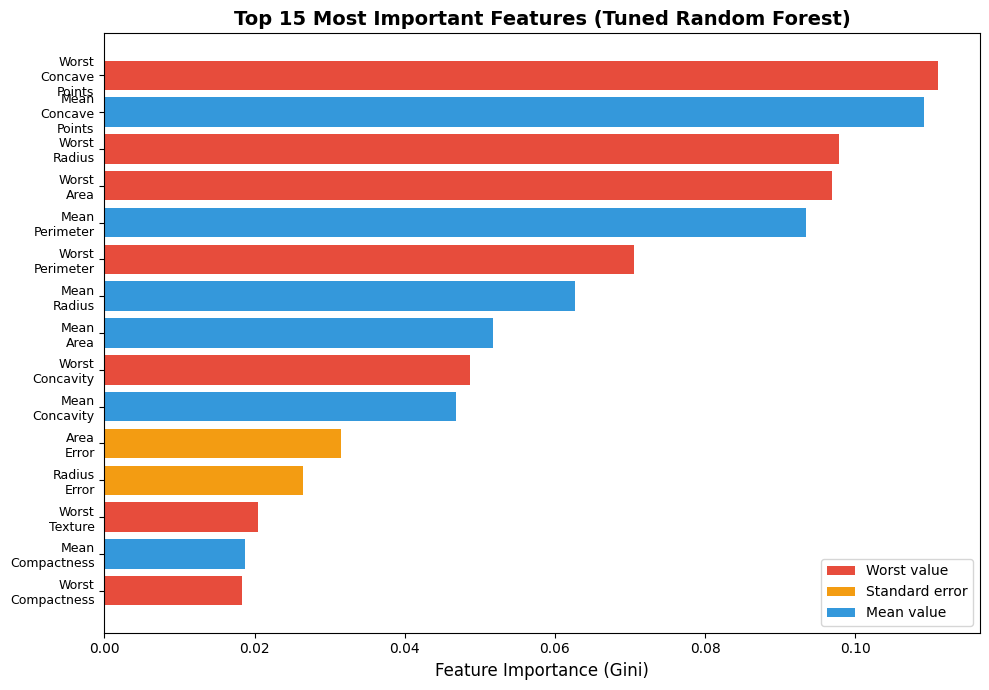


Top 10 features:
worst concave points    0.1110
mean concave points     0.1092
worst radius            0.0978
worst area              0.0969
mean perimeter          0.0934
worst perimeter         0.0705
mean radius             0.0627
mean area               0.0518
worst concavity         0.0486
mean concavity          0.0468


In [17]:
feature_importance = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = feature_importance.nlargest(15)

# Color by feature group
def feature_color(name):
    if 'worst' in name:  return '#e74c3c'
    if 'error' in name:  return '#f39c12'
    return '#3498db'

bar_colors = [feature_color(f) for f in top_features.index]

plt.figure(figsize=(10, 7))
plt.barh(range(len(top_features)), top_features.values, color=bar_colors)
plt.yticks(range(len(top_features)),
           [f.replace(' ', '\n').title() for f in top_features.index], fontsize=9)
plt.xlabel('Feature Importance (Gini)', fontsize=12)
plt.title('Top 15 Most Important Features (Tuned Random Forest)',
          fontsize=14, fontweight='bold')

legend_handles = [
    mpatches.Patch(facecolor='#e74c3c', label='Worst value'),
    mpatches.Patch(facecolor='#f39c12', label='Standard error'),
    mpatches.Patch(facecolor='#3498db', label='Mean value'),
]
plt.legend(handles=legend_handles, loc='lower right')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(top_features.head(10).round(4).to_string())

### 5.4 Threshold Tuning — Clinical Decision

The default classification threshold is 0.5, but in medicine we can adjust it.

- **Lower threshold** → more positives flagged → higher sensitivity, fewer missed cancers, but more unnecessary biopsies
- **Higher threshold** → fewer positives → fewer biopsies, but more missed cancers

We identify the threshold that achieves **≥ 97% sensitivity** (missing at most 3% of cancers) while maximizing specificity.

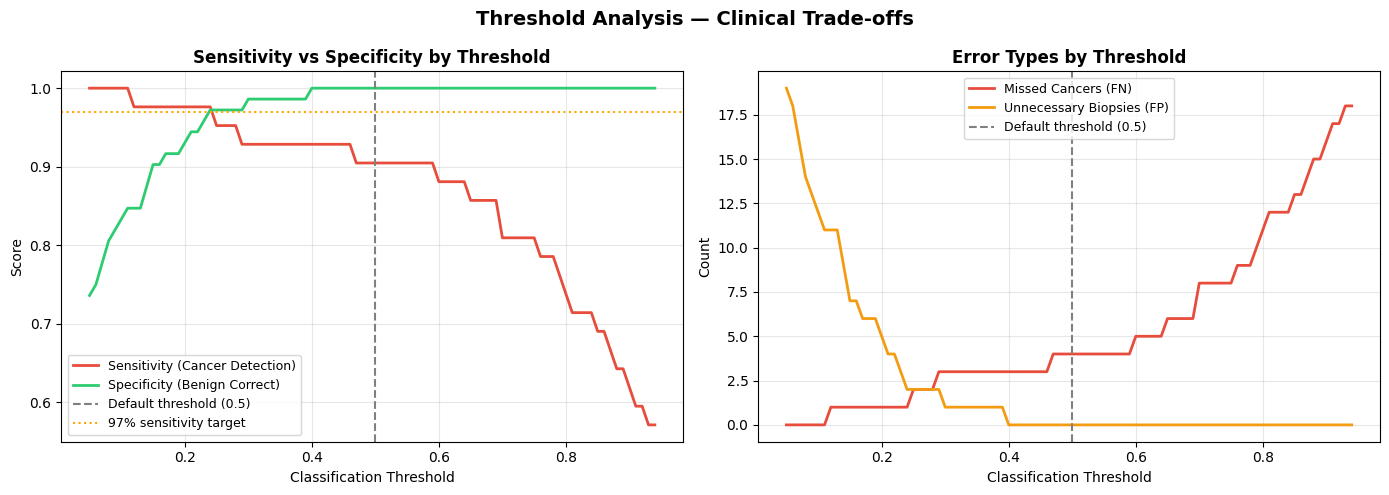

Recommended Clinical Threshold: 0.24
  Sensitivity: 0.9762
  Specificity: 0.9722
  Missed Cancers (FN):    1
  Unnecessary Biopsies (FP): 2


In [18]:
thresholds = np.arange(0.05, 0.95, 0.01)
thresh_results = []

for t in thresholds:
    y_pred_t = (y_prob_best_rf >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_test, y_pred_t).ravel()
    thresh_results.append({
        'Threshold':   round(t, 2),
        'Sensitivity': tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0,
        'Specificity': tn_t / (tn_t + fp_t) if (tn_t + fp_t) > 0 else 0,
        'FN':          fn_t,
        'FP':          fp_t
    })

thresh_df = pd.DataFrame(thresh_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sensitivity vs Specificity
axes[0].plot(thresh_df['Threshold'], thresh_df['Sensitivity'],
             label='Sensitivity (Cancer Detection)', color=MALIGNANT_COLOR, linewidth=2)
axes[0].plot(thresh_df['Threshold'], thresh_df['Specificity'],
             label='Specificity (Benign Correct)', color=BENIGN_COLOR, linewidth=2)
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[0].axhline(y=0.97, color='orange', linestyle=':', linewidth=1.5, label='97% sensitivity target')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Sensitivity vs Specificity by Threshold', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Error types
axes[1].plot(thresh_df['Threshold'], thresh_df['FN'],
             label='Missed Cancers (FN)', color=MALIGNANT_COLOR, linewidth=2)
axes[1].plot(thresh_df['Threshold'], thresh_df['FP'],
             label='Unnecessary Biopsies (FP)', color='#f39c12', linewidth=2)
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Types by Threshold', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Analysis — Clinical Trade-offs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Recommend threshold: >=97% sensitivity, maximize specificity
clinical = thresh_df[thresh_df['Sensitivity'] >= 0.97].nlargest(1, 'Specificity')
if not clinical.empty:
    rec = clinical.iloc[0]
    print(f'Recommended Clinical Threshold: {rec["Threshold"]:.2f}')
    print(f'  Sensitivity: {rec["Sensitivity"]:.4f}')
    print(f'  Specificity: {rec["Specificity"]:.4f}')
    print(f'  Missed Cancers (FN):    {int(rec["FN"])}')
    print(f'  Unnecessary Biopsies (FP): {int(rec["FP"])}')

---
## Summary & Business Interpretation

### Answer to the Business Question

> *Can we develop a ML model to assist radiologists in distinguishing malignant from benign breast masses, to reduce unnecessary biopsies while maintaining high cancer detection rates?*

**Yes.** All three models significantly outperform random chance (AUC ≈ 0.99). The **Tuned Random Forest** achieves the strongest overall performance.

### Clinical Interpretation

| Priority | Metric | Why It Matters |
|---|---|---|
| **#1** | Sensitivity (Recall) | Missing a cancer has catastrophic consequences — must stay high |
| **#2** | Specificity | Correctly ruling out benign reduces unnecessary biopsies and patient anxiety |
| **#3** | AUC-ROC | Overall discriminative ability across all thresholds |

### Key Findings

- **"Worst" features dominate** — the largest/most abnormal nucleus measurements in each image are the strongest predictors
- **Concave points, radius, and perimeter** are consistently the most important features
- **Threshold tuning** allows the model to be calibrated to clinical priorities — a lower threshold catches more cancers at the cost of more false alarms

### Limitations & Next Steps

- Dataset is 569 patients — real clinical deployment requires larger, more diverse cohorts
- FNA features are computed features, not raw images — deep learning on raw images may improve further
- External validation on a different hospital's data is required before clinical use
- Model decisions should be explainable to radiologists — consider SHAP values for individual prediction explanations